In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [9]:
df = pd.read_csv("/Users/madhavathavale/Library/Mobile Documents/com~apple~CloudDocs/workspace/python/Krish-Naik-complete-Data-Science/3-Complete Linear Regression/Practicals/economic_index.csv")

In [5]:
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [10]:
df.drop(columns=["Unnamed: 0", "year", "month"],axis = 1,inplace=True)

In [8]:
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [12]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

/Users/madhavathavale/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/madhavathavale/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/madhavathavale/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


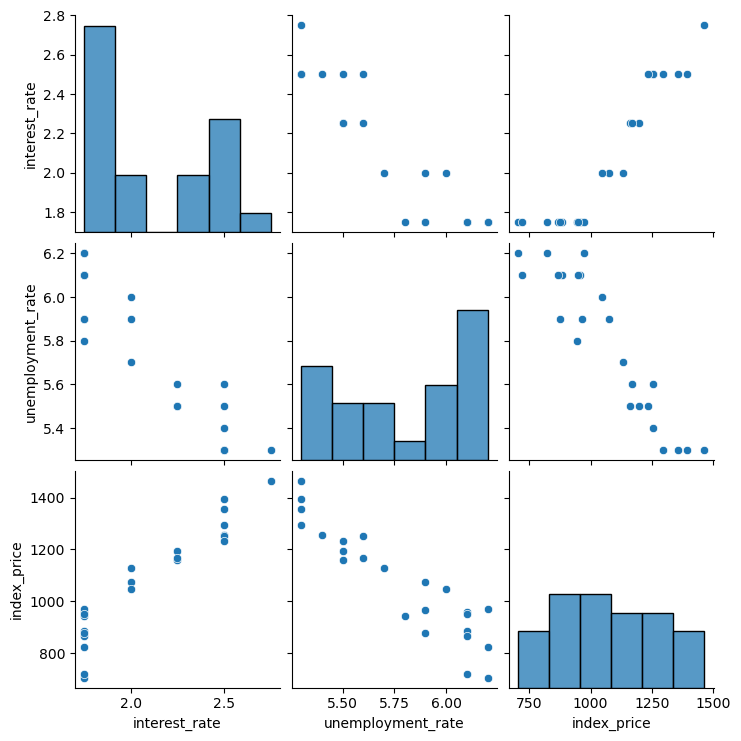

In [13]:
sns.pairplot(df)

In [14]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


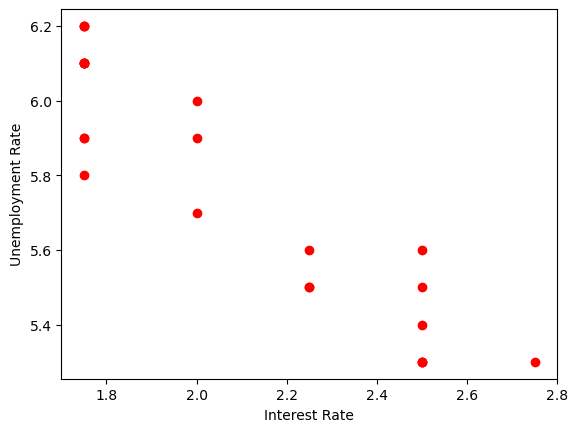

In [15]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],c='red')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.show()

In [16]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1] 

In [17]:
X.head()


,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [18]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [75]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

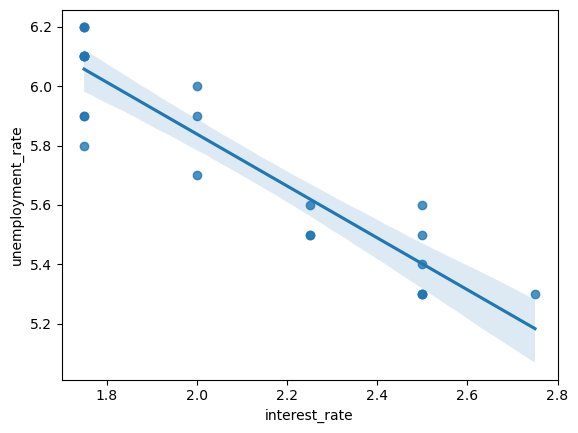

In [76]:
sns.regplot(x='interest_rate',y='unemployment_rate',data=df)

<Axes: xlabel='interest_rate', ylabel='index_price'>

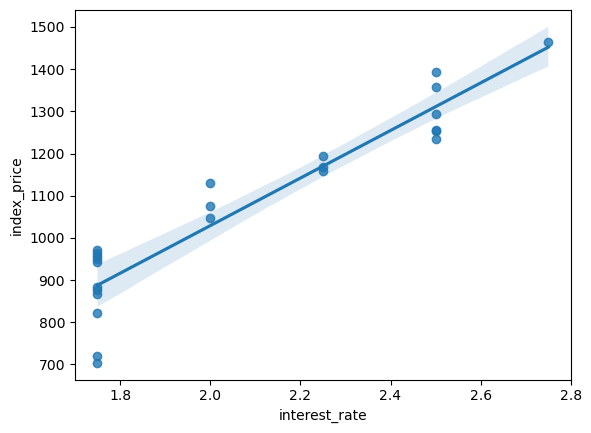

In [77]:
sns.regplot(x='interest_rate',y='index_price',data=df)

In [78]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


In [80]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [81]:
X_train

array([[-1.01512945,  0.39413171],
       [-1.01512945,  0.98532928],
       [-1.01512945,  1.28092806],
       [ 0.3904344 , -0.78826342],
       [ 1.09321633, -0.78826342],
       [-1.01512945,  0.98532928],
       [ 1.09321633, -1.08386221],
       [ 1.09321633, -1.37946099],
       [ 1.09321633, -0.49266464],
       [-1.01512945,  0.98532928],
       [ 0.3904344 , -0.49266464],
       [ 0.3904344 , -0.78826342],
       [-1.01512945,  0.98532928],
       [ 1.09321633, -1.37946099],
       [ 1.79599826, -1.37946099],
       [-1.01512945,  1.28092806],
       [-1.01512945,  0.98532928],
       [-0.31234752,  0.68973049]])

In [82]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


In [83]:
lr.fit(X_train,y_train)

LinearRegression()

In [84]:
# cross validation
from sklearn.model_selection import cross_val_score
mse = cross_val_score(lr,X_train,y_train,scoring='neg_mean_squared_error',cv=3)
mean_mse = np.mean(mse)

In [85]:
print(mean_mse)

-3875.275040189867


In [86]:
y_pred = lr.predict(X_test)

In [88]:
y_pred

array([1022.11617625, 1053.1882909 ,  876.8775728 ,  939.0218021 ,
        923.48574478, 1312.59338314])

In [89]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error : ",mean_squared_error(y_test,y_pred))
print("Mean Absolute Error : ",mean_absolute_error(y_test,y_pred))  
print("RMSE " , np.sqrt(mean_squared_error(y_test,y_pred)))

Mean Squared Error :  7913.525322008833
Mean Absolute Error :  72.57394419881075
RMSE  88.95799751573118


In [90]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print("R^2 : ",score)

R^2 :  0.8313408388278934


In [91]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)   # Adjusted R^2

0.7189013980464891

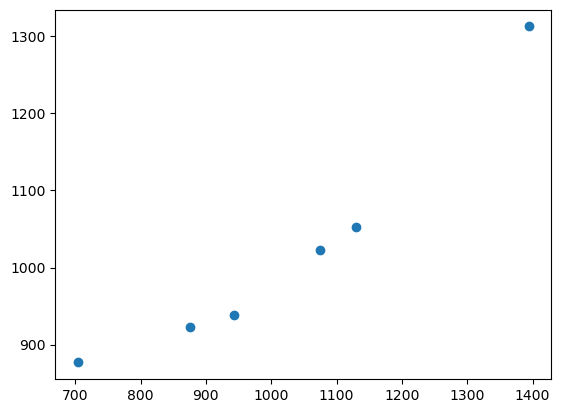

In [92]:
plt.scatter(y_test,y_pred)


In [93]:
residuals = y_test - y_pred
print(residuals)



11     52.883824
10     76.811709
22   -172.877573
14      3.978198
20    -47.485745
1      81.406617
Name: index_price, dtype: float64


/var/folders/48/ngbdqk2j545_fx71g2khfp6r0000gn/T/ipykernel_24125/2665350104.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals)
/Users/madhavathavale/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='index_price', ylabel='Density'>

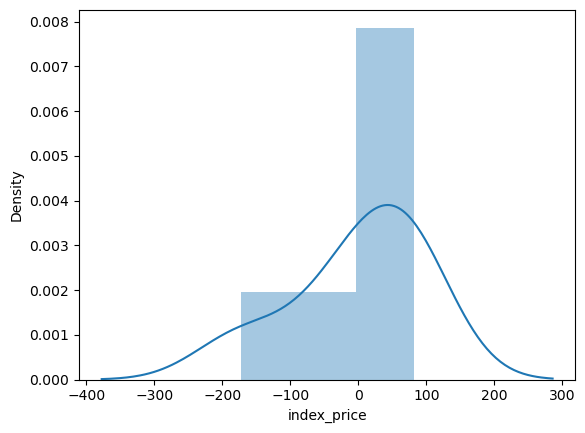

In [94]:
sns.distplot(residuals)

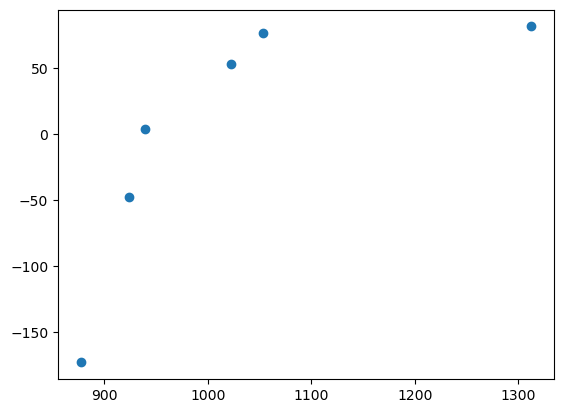

In [95]:
plt.scatter(y_pred,residuals)

In [96]:
import statsmodels.api as sm

In [97]:
model = sm.OLS(y_train,X_train).fit()

In [98]:
prediction = model.predict(X_test)

In [99]:
prediction

array([ -64.55049042,  -33.47837577, -209.78909387, -147.64486456,
       -163.18092189,  225.92671647])

In [102]:
print("coeffcient : ",lr.coef_)
print("Intercept : ",lr.intercept_)
print("R^2 : ",lr.score(X_train,y_train))

coeffcient :  [140.34286806 -52.55792038]
Intercept :  1086.6666666666667
R^2 :  0.9117914482707675


In [101]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.030
Model:                            OLS   Adj. R-squared (uncentered):             -0.091
Method:                 Least Squares   F-statistic:                             0.2464
Date:                Fri, 14 Mar 2025   Prob (F-statistic):                       0.785
Time:                        13:36:29   Log-Likelihood:                         -151.40
No. Observations:                  18   AIC:                                      306.8
Df Residuals:                      16   BIC:                                      308.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/Users/madhavathavale/anaconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
